Решается задача исследования уверенности модели при классификации текстов. В качестве базовой модели выбрана Qwen2.5-1.5B-Instruct.

# Считыввание данных


In [ ]:
import pandas as pd

# train_df = pd.read_csv("train_clinc.csv")
# test_df = pd.read_csv("test_clinc.csv")
# train_df = pd.read_csv("train_grnti.csv")
test_df = pd.read_csv("test_grnti.csv")

print("Размер test:", test_df.shape)
print(test_df.head())

Размер test: (1000, 3)
       id                                               text  label
0  178587  ВЫСОКОВОЛЬТНЫЕ ЯВЛЕНИЯ В РАСПЛАВЛЕННЫХ ХЛОРИДН...  Химия
1   61924  Каталитическое карбонилирование α-олефинов в п...  Химия
2  165778  ВЛИЯНИЕ ТЕМПЕРАТУРЫ И КОНЦЕНТРАЦИИ НА ГИДРАТАЦ...  Химия
3  126942  ОПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТОВ ДИФФУЗИИ АМЕРИЦИЯ И ...  Химия
4   54173  ОБЩЕЕ ПРЕДСТАВЛЕНИЕ О НУКЛЕАЗАХ ИЗ ЯДА ЗМЕЙ: Д...  Химия


In [ ]:
import pandas as pd

# train_df = pd.read_csv("train_clinc.csv")
# test_df = pd.read_csv("test_clinc.csv")
# train_df = pd.read_csv("train_grnti.csv")
test_df = pd.read_csv("test_clinc.csv")

print("Размер test:", test_df.shape)
print(test_df.head())

Размер test: (100, 3)
    id                                               text        label
0  297            Можешь найти мне рецепт медового хлеба?       рецепт
1  794                    Вы можете рассчитать мой налог?       налоги
2  805  Нужно ли мне делать прививки или что-то еще пе...      вакцины
3   46             что осталось на моих банковских счетах       баланс
4  998  Можете ли вы сказать мне все напоминания я уст...  напоминание


In [ ]:
test_df["label"].unique()

array(['рецепт', 'налоги', 'вакцины', 'баланс', 'напоминание', 'погода',
       'пробки', 'перевод', 'бензин', 'музыка'], dtype=object)

# Qwen вербализация



In [ ]:
import torch
import re
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
print("\nLoading model...")
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)


Loading model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [ ]:

selected_classes = [ #грнти
    "Энергетика",
    "Языкознание",
    "Психология",
    "Философия",
    "Биология",
    "Геология",
    "Химия",
    "Транспорт",
    "Физика",
    "Математика"
]


In [ ]:
selected_classes = [  #клинк
     "баланс",
   "бензин",
   "рецепт",
   "музыка",
   "пробки",
   "перевод",
   "погода",
   "налоги",
   "вакцины",
   "напоминание"
]

In [ ]:
test_10 = test_df[test_df["label"].isin(selected_classes)].copy()

# Создаём отображение
label2id = {label: i for i, label in enumerate(selected_classes)}
id2label = {v: k for k, v in label2id.items()}


test_10["label_id"] = test_10["label"].map(label2id)

print(f"Test samples after filtering: {len(test_10)}")
print(f"Columns in test_10: {test_10.columns.tolist()}")

Test samples after filtering: 100
Columns in test_10: ['id', 'text', 'label', 'label_id']


In [ ]:
test_10.head()

,id,text,label,label_id
1,794,Вы можете рассчитать мой налог?,налоги,7
2,805,Нужно ли мне делать прививки или что-то еще пе...,вакцины,8
3,46,что осталось на моих банковских счетах,баланс,0
4,998,Можете ли вы сказать мне все напоминания я уст...,напоминание,9
5,620,идет дождь,погода,6


In [ ]:
def create_classification_prompt(text, classes_list):
    """Создаёт промпт для классификации статьи по её тексту"""
    classes_str = ", ".join(classes_list)

    prompt_1 = f"""<|im_start|>system
Ты — эксперт по научной классификации. Твоя задача — отнести научную статью к одной из рубрик ГРНТИ.

Доступные рубрики: {classes_str}

Правила:
1. Выбери ТОЛЬКО ОДНУ рубрику из списка
2. Оцени свою уверенность числом от 0 до 1
3. Ответь строго в формате: КЛАСС: [название рубрики] | УВЕРЕННОСТЬ: [число]
4. Не добавляй пояснений, рассуждений и другого текста
<|im_end|>
<|im_start|>user
Текст статьи:
{text}

Определи рубрику ГРНТИ и укажи уверенность.
<|im_end|>
<|im_start|>assistant
"""
    prompt = f"""<|im_start|>system
Ты — эксперт по классификации интентов. Твоя задача — отнести запрос пользователя к одной из категорий интентов.

Доступные категории: {classes_str}

Правила:
1. Выбери ТОЛЬКО ОДНУ категорию из списка
2. Оцени свою уверенность числом от 0 до 1
3. Ответь строго в формате: КЛАСС: [название категории] | УВЕРЕННОСТЬ: [число]
4. Не добавляй пояснений, рассуждений и другого текста
<|im_end|>
<|im_start|>user
Запрос пользователя:
{text}

Определи категорию интента и укажи уверенность.
<|im_end|>
<|im_start|>assistant
"""
    return prompt

def get_prediction(text, classes_list, max_retries=3):
    """Получает предсказание от модели"""
    prompt = create_classification_prompt(text, classes_list)

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            temperature=0.0,
            do_sample=False,
            top_p=0.95,
            top_k=50,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

    return parse_llm_response(response)

def parse_llm_response(response):
    """Парсит ответ модели и нормализует предсказанный класс"""
    # Ищем класс
    class_match = re.search(r'КЛАСС:\s*([^|\n]+)', response, re.IGNORECASE)
    # Ищем уверенность
    conf_match = re.search(r'УВЕРЕННОСТЬ:\s*([\d.]+)', response, re.IGNORECASE)

    predicted_class = class_match.group(1).strip() if class_match else None
    confidence = float(conf_match.group(1)) if conf_match else None

    # Нормализация: приводим к нижнему регистру и убираем лишние пробелы
    if predicted_class:
        predicted_class = predicted_class.lower().strip()
        # Обработка вариантов "рецепт" и "рецепты" как одного класса
        if predicted_class == "рецепты":
            predicted_class = "рецепт"

    return {
        'predicted_class': predicted_class,
        'confidence': confidence,
        'raw_response': response
    }

    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    print(response)

    return parse_llm_response(response)

In [ ]:
import tqdm
import re

In [ ]:
import time
from tqdm import tqdm

# ==================== 4. ИНФЕРЕНС НА ТЕСТОВОЙ ВЫБОРКЕ ====================

print(f"\nRunning inference on {len(test_10)} samples...")

results = []
failed_samples = []

# Начало замера времени
start_time = time.time()

for idx, row in tqdm(test_10.iterrows(), total=len(test_10)):
    try:
        pred = get_prediction(
            text=row['text'],
            classes_list=selected_classes
        )

        results.append({
            'id': row.get('id', idx),
            'text': row['text'][:200] + '...',
            'true_label': row['label'],
            'true_label_id': row['label_id'],
            'predicted_label': pred['predicted_class'],
            'confidence': pred['confidence'],
            'raw_response': pred['raw_response']
        })

    except Exception as e:
        print(f"\nError at index {idx}: {e}")
        failed_samples.append({
            'index': idx,
            'error': str(e)
        })

# Окончание замера времени
end_time = time.time()
total_time = end_time - start_time
n_examples = len(test_10) - len(failed_samples)

# Вывод статистики времени
print("\n" + "=" * 40)
print("Статистика времени инференса:")
print(f"Всего примеров: {n_examples} (успешно обработано)")
print(f"Общее время: {total_time:.2f} сек")
if n_examples > 0:
    print(f"Среднее время на один пример: {total_time / n_examples:.3f} сек")
print("=" * 40)


Running inference on 100 samples...


100%|██████████| 100/100 [01:54<00:00,  1.14s/it]


Статистика времени инференса:
Всего примеров: 100 (успешно обработано)
Общее время: 114.42 сек
Среднее время на один пример: 1.144 сек


In [ ]:
 #==================== 5. АНАЛИЗ РЕЗУЛЬТАТОВ ====================

results_df = pd.DataFrame(results)

print("\n" + "="*50)
print("RESULTS SUMMARY")
print("="*50)

print(f"\nTotal processed: {len(results_df)}")
print(f"Failed samples: {len(failed_samples)}")

# Сопоставляем предсказанные классы с ID
def map_prediction_to_id(pred_class):
    if pred_class in label2id:
        return label2id[pred_class]
    return -1

results_df['predicted_label_id'] = results_df['predicted_label'].apply(map_prediction_to_id)

# Вычисляем accuracy
correct = (results_df['true_label_id'] == results_df['predicted_label_id']).sum()
accuracy = correct / len(results_df) if len(results_df) > 0 else 0
print(f"\nAccuracy: {accuracy:.4f} ({correct}/{len(results_df)})")

# Матрица ошибок
from sklearn.metrics import confusion_matrix, classification_report

y_true = results_df['true_label_id'].values
y_pred = results_df['predicted_label_id'].values

# Фильтруем только валидные предсказания
all_labels = list(range(len(selected_classes)))
valid_mask = y_pred != -1
if valid_mask.sum() > 0:
    print(f"\nClassification Report (on valid predictions):")
    print(classification_report(
        y_true[valid_mask],
        y_pred[valid_mask],
        labels=all_labels,
        target_names=selected_classes
    ))

# Анализ уверенности
print("\n" + "="*50)
print("CONFIDENCE ANALYSIS")
print("="*50)

print(f"\nAverage confidence: {results_df['confidence'].mean():.4f}")
print(f"Median confidence: {results_df['confidence'].median():.4f}")
print(f"Std confidence: {results_df['confidence'].std():.4f}")

# Уверенность для правильных и неправильных ответов
correct_df = results_df[results_df['true_label_id'] == results_df['predicted_label_id']]
incorrect_df = results_df[results_df['true_label_id'] != results_df['predicted_label_id']]

if len(correct_df) > 0:
    print(f"\nAvg confidence (correct): {correct_df['confidence'].mean():.4f}")
if len(incorrect_df) > 0:
    print(f"Avg confidence (incorrect): {incorrect_df['confidence'].mean():.4f}")




RESULTS SUMMARY

Total processed: 100
Failed samples: 0

Accuracy: 0.9000 (90/100)

Classification Report (on valid predictions):
              precision    recall  f1-score   support

      баланс       0.77      1.00      0.87        10
      бензин       0.92      0.92      0.92        12
      рецепт       0.50      0.80      0.62         5
      музыка       0.71      1.00      0.83         5
      пробки       1.00      0.90      0.95        10
     перевод       1.00      0.29      0.44         7
      погода       1.00      1.00      1.00         9
      налоги       1.00      1.00      1.00        13
     вакцины       1.00      1.00      1.00        12
 напоминание       1.00      0.88      0.94        17

    accuracy                           0.90       100
   macro avg       0.89      0.88      0.86       100
weighted avg       0.93      0.90      0.89       100


CONFIDENCE ANALYSIS

Average confidence: 0.9715
Median confidence: 1.0000
Std confidence: 0.0440

Avg confide

In [ ]:
print("Raw responses (first 50):")
for i in range(min(15, len(results_df))):
    print(f"\n--- Sample {i+1} ---")
    print(f"True: {results_df.iloc[i]['true_label']}")
    print(f"Predicted: {results_df.iloc[i]['predicted_label']}")
    print(f"Raw response:\n{results_df.iloc[i]['raw_response']}")
    print("-" * 50)

Raw responses (first 50):

--- Sample 1 ---
True: рецепт
Predicted: рецепт
Raw response:
КЛАСС: рецепты | УВЕРЕННОСТЬ: 0.95
--------------------------------------------------

--- Sample 2 ---
True: налоги
Predicted: налоги
Raw response:
КЛАСС: налоги | УВЕРЕННОСТЬ: 1
--------------------------------------------------

--- Sample 3 ---
True: вакцины
Predicted: вакцины
Raw response:
КЛАСС: вакцины | УВЕРЕННОСТЬ: 0.9
--------------------------------------------------

--- Sample 4 ---
True: баланс
Predicted: баланс
Raw response:
КЛАСС: баланс | УВЕРЕННОСТЬ: 1
--------------------------------------------------

--- Sample 5 ---
True: напоминание
Predicted: напоминание
Raw response:
КЛАСС: напоминание | УВЕРЕННОСТЬ: 1
--------------------------------------------------

--- Sample 6 ---
True: погода
Predicted: погода
Raw response:
КЛАСС: погода | УВЕРЕННОСТЬ: 1
--------------------------------------------------

--- Sample 7 ---
True: вакцины
Predicted: вакцины
Raw response:
КЛАСС: вакцины 

AUROC (confidence): 0.8644
AUARC (confidence): 0.9764


/tmp/ipykernel_14328/1959531436.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auarc = np.trapz(accuracies, x=rejection_rates)


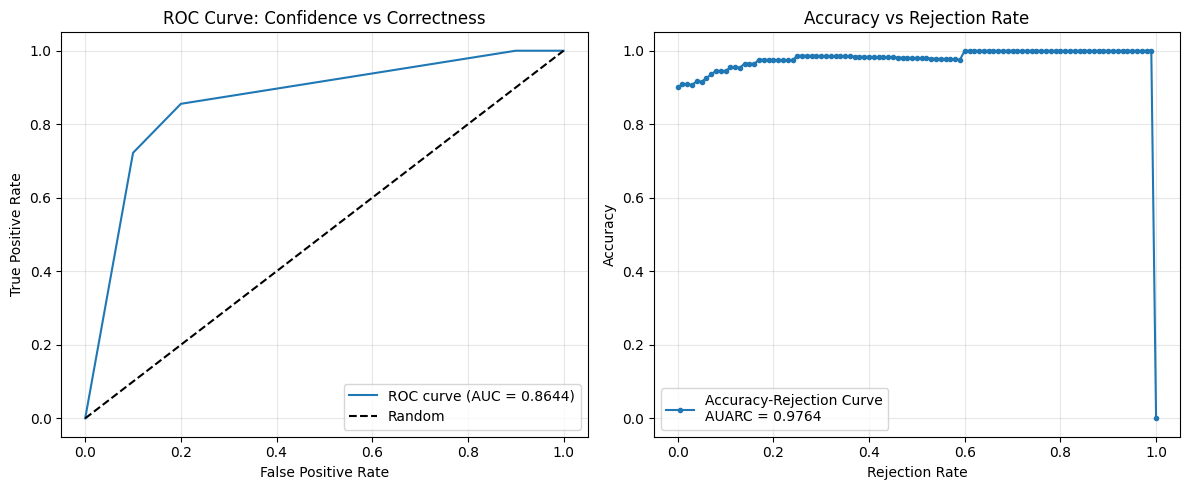

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Предполагаем, что results уже заполнен
# results = [...]

# 1. Преобразуем результаты в DataFrame
df = pd.DataFrame(results)

# 2. Добавим столбец корректности предсказания
df['is_correct'] = (df['predicted_label'] == df['true_label']).astype(int)

# 3. Вычислим AUROC для confidence
#    (бинарная классификация: правильность vs неправильность)
if df['is_correct'].nunique() >= 2:  # есть и 0, и 1
    auroc_conf = roc_auc_score(df['is_correct'], df['confidence'])
    print(f"AUROC (confidence): {auroc_conf:.4f}")
else:
    print("Все предсказания одинаковы (все верны или все неверны), AUROC не определён.")
    auroc_conf = None

# 4. Функция для вычисления AUARC
def compute_auarc(df, confidence_col='confidence', correct_col='is_correct'):
    """
    Вычисляет Area Under Accuracy-Rejection Curve.
    Возвращает auarc, массивы rejection_rates и accuracies.
    """
    # Сортируем по убыванию confidence (самые уверенные первые)
    sorted_df = df.sort_values(by=confidence_col, ascending=False).reset_index(drop=True)
    n = len(sorted_df)
    accuracies = []
    rejection_rates = []

    for k in range(n + 1):
        accepted = sorted_df.iloc[:n - k]  # принимаем top N-k примеров
        if len(accepted) == 0:
            acc = 0.0
        else:
            acc = accepted[correct_col].mean()
        accuracies.append(acc)
        rejection_rates.append(k / n)

    # Интегрируем методом трапеций
    auarc = np.trapz(accuracies, x=rejection_rates)
    return auarc, rejection_rates, accuracies

# 5. Вычисляем AUARC для confidence
auarc_conf, rej_rates, acc_vals = compute_auarc(df)
print(f"AUARC (confidence): {auarc_conf:.4f}")

# 6. Визуализация

# 6.1 ROC-кривая для confidence (если AUROC был вычислен)
if auroc_conf is not None:
    fpr, tpr, _ = roc_curve(df['is_correct'], df['confidence'])
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auroc_conf:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve: Confidence vs Correctness')
    plt.legend()
    plt.grid(alpha=0.3)

    # 6.2 Кривая Accuracy-Rejection (AUARC)
    plt.subplot(1, 2, 2)
    plt.plot(rej_rates, acc_vals, marker='o', markersize=3, linewidth=1.5,
             label=f'Accuracy-Rejection Curve\nAUARC = {auarc_conf:.4f}')
    plt.xlabel('Rejection Rate')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Rejection Rate')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    # Если AUROC не определён, строим только кривую Accuracy-Rejection
    plt.figure(figsize=(6, 5))
    plt.plot(rej_rates, acc_vals, marker='o', markersize=3, linewidth=1.5,
             label=f'Accuracy-Rejection Curve\nAUARC = {auarc_conf:.4f}')
    plt.xlabel('Rejection Rate')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Rejection Rate')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()